## 1. Imports & Configuration

In [1]:
# ============================================================
# CELL 1 — IMPORTS & CONFIGURATION
# ============================================================
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

# ---------- Paths ----------
DATA_DIR = "data_output"
TREE_TRAIN_PATH   = os.path.join(DATA_DIR, "2_data_preprocessed_tree_train.csv")
TREE_TEST_PATH    = os.path.join(DATA_DIR, "2_data_preprocessed_tree_test.csv")
LINEAR_TRAIN_PATH = os.path.join(DATA_DIR, "3_data_preprocessed_linear_train.csv")
LINEAR_TEST_PATH  = os.path.join(DATA_DIR, "3_data_preprocessed_linear_test.csv")

TARGET_COL = "Khoảng giá"

# Whether the target column was log1p-transformed during preprocessing.
# True  → predictions are decoded with expm1 before evaluation.
# False → predictions are used as-is.
IS_TARGET_LOGGED = True

# Short display names for charts
MODEL_ABBR = {
    "Random Forest":    "RF",
    "Gradient Boosting": "GBDT",
    "XGBoost":          "XGB",
    "LightGBM":         "LGBM",
    "Linear Regression": "LR",
    "Ridge Regression":  "Ridge",
    "Lasso Regression":  "Lasso",
    "ElasticNet":        "ENet",
}

METRICS = ["R2 Score", "MAE", "MSE", "MAPE", "RMSLE"]

IEEE_RC = {
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":         6,
    "axes.titlesize":    7,
    "axes.labelsize":    6,
    "xtick.labelsize":   5,
    "ytick.labelsize":   5,
    "font.weight":       "normal",
    "axes.titleweight":  "normal",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
}

## 2. Data Loading & Sanity Checks

In [2]:
# ============================================================
# CELL 2 — DATA LOADING & SANITY CHECKS
# ============================================================
df_train_tree   = pd.read_csv(TREE_TRAIN_PATH)
df_test_tree    = pd.read_csv(TREE_TEST_PATH)
df_train_linear = pd.read_csv(LINEAR_TRAIN_PATH)
df_test_linear  = pd.read_csv(LINEAR_TEST_PATH)

for name, df in [
    ("df_train_tree",   df_train_tree),
    ("df_test_tree",    df_test_tree),
    ("df_train_linear", df_train_linear),
    ("df_test_linear",  df_test_linear),
]:
    assert df.shape[0] > 0,          f"{name} is empty"
    assert TARGET_COL in df.columns, f"'{TARGET_COL}' not found in {name}"

# ---------- Split features / target ----------
X_train_tree = df_train_tree.drop(columns=[TARGET_COL])
y_train_tree = df_train_tree[TARGET_COL]

X_test_tree  = df_test_tree.drop(columns=[TARGET_COL])
y_test_tree  = df_test_tree[TARGET_COL]

X_train_linear = df_train_linear.drop(columns=[TARGET_COL])
y_train_linear = df_train_linear[TARGET_COL]

X_test_linear  = df_test_linear.drop(columns=[TARGET_COL])
y_test_linear  = df_test_linear[TARGET_COL]

print(f"Tree  train : {X_train_tree.shape}  |  test : {X_test_tree.shape}")
print(f"Linear train: {X_train_linear.shape}  |  test : {X_test_linear.shape}")

Tree  train : (4645, 22)  |  test : (1164, 22)
Linear train: (4645, 22)  |  test : (1164, 22)


## 3. Shared Utilities

In [3]:
# ============================================================
# CELL 3 — SHARED UTILITIES
# ============================================================
def decode_target(arr: np.ndarray, is_logged: bool) -> np.ndarray:
    """Reverse log1p transformation when IS_TARGET_LOGGED is True."""
    return np.expm1(arr) if is_logged else arr


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Return a dict of evaluation metrics on original-scale values."""
    y_pred_clipped = np.clip(y_pred, 0, None)
    return {
        "R2 Score": round(r2_score(y_true, y_pred), 4),
        "MAE":      round(mean_absolute_error(y_true, y_pred), 2),
        "MSE":      round(mean_squared_error(y_true, y_pred), 2),
        "MAPE":     round(mean_absolute_percentage_error(y_true, y_pred), 4),
        "RMSLE":    round(np.sqrt(mean_squared_log_error(y_true, y_pred_clipped)), 4),
    }


def run_experiment(
    models: dict,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    is_logged: bool = False,
) -> pd.DataFrame:
    """
    Train every model in `models`, evaluate, and return a results DataFrame.

    Parameters
    ----------
    models    : {name: estimator} dict
    X_train/y_train : training arrays
    X_test/y_test   : evaluation arrays (already in original scale)
    is_logged : if True, decode predictions with expm1 before evaluation
    """
    assert len(X_train) == len(y_train), (
        f"Size mismatch: X_train={len(X_train)}, y_train={len(y_train)}"
    )

    records = []
    for name, model in models.items():
        try:
            model.fit(X_train, y_train)
            preds_raw  = model.predict(X_test)
            preds_eval = decode_target(preds_raw, is_logged)
            row = {"Model": name, "Status": "Success"}
            row.update(compute_metrics(y_test, preds_eval))
        except Exception as exc:
            row = {
                "Model": name, "Status": f"Failed ({type(exc).__name__})",
                **{m: np.nan for m in METRICS},
            }
            print(f"  [FAIL] {name}: {exc}")
        records.append(row)
        print(f"  [OK]   {name}")

    return pd.DataFrame(records)


def missing_value_check(X: pd.DataFrame, label: str) -> None:
    """Print a per-column NaN count summary."""
    total = X.isna().sum().sum()
    if total == 0:
        print(f"  {label}: no missing values")
    else:
        detail = X.isna().sum()
        print(f"  {label}: {total} NaN total")
        print(detail[detail > 0].to_string())


def impute_median(
    X_train: pd.DataFrame, X_test: pd.DataFrame
) -> tuple[np.ndarray, np.ndarray]:
    """Fit a median imputer on train, transform both splits."""
    imp = SimpleImputer(strategy="median")
    return imp.fit_transform(X_train), imp.transform(X_test)


def scale_standard(
    X_train: np.ndarray, X_test: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Fit StandardScaler on train, transform both splits."""
    sc = StandardScaler()
    return sc.fit_transform(X_train), sc.transform(X_test)

## 4. Missing Value Report

In [4]:
# ============================================================
# CELL 4 — MISSING VALUE REPORT (LINEAR SPLITS)
# ============================================================
print("=== Missing Value Check ===")
missing_value_check(X_train_linear, "X_train_linear")
missing_value_check(X_test_linear,  "X_test_linear")

=== Missing Value Check ===
  X_train_linear: 3862 NaN total
Dien_Tich_Lo          961
Ty_Le_Giao_Thong      967
Ty_Le_Cong_Cong_CX    967
Ty_Le_Dat_O           967
  X_test_linear: 913 NaN total
Dien_Tich_Lo          226
Ty_Le_Giao_Thong      229
Ty_Le_Cong_Cong_CX    229
Ty_Le_Dat_O           229


## 5. Preprocessing: Imputation & Scaling

In [5]:
# ============================================================
# CELL 5 — PREPROCESSING: IMPUTATION + SCALING (LINEAR)
# ============================================================
X_train_imp, X_test_imp = impute_median(X_train_linear, X_test_linear)
X_train_scaled, X_test_scaled = scale_standard(X_train_imp, X_test_imp)

assert np.isnan(X_train_scaled).sum() == 0, "NaN remaining after imputation (train)"
assert np.isnan(X_test_scaled).sum()  == 0, "NaN remaining after imputation (test)"

print(f"Linear train scaled: {X_train_scaled.shape}")
print(f"Linear test  scaled: {X_test_scaled.shape}")

Linear train scaled: (4645, 22)
Linear test  scaled: (1164, 22)


## 6. Experiment A — Tree-based Models

In [6]:
# ============================================================
# CELL 6 — EXPERIMENT A: TREE-BASED MODELS
# ============================================================
print("\n=== Experiment A: Tree-based Models ===")

tree_models = {
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42,
                                      n_jobs=-1, verbosity=0),
    "LightGBM":          LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42,
                                       n_jobs=-1, verbose=-1),
}

# Tree models use original-scale targets; decode if the CSV was saved log1p
y_test_tree_eval = decode_target(y_test_tree.values, IS_TARGET_LOGGED)

results_tree = run_experiment(
    models=tree_models,
    X_train=X_train_tree.values,
    y_train=y_train_tree.values,
    X_test=X_test_tree.values,
    y_test=y_test_tree_eval,
    is_logged=IS_TARGET_LOGGED,
)

display(results_tree)


=== Experiment A: Tree-based Models ===
  [OK]   Random Forest
  [FAIL] Gradient Boosting: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
  [OK]   Gradient Boosting
  [OK]   XGBoost
  [OK]   LightGBM


,Model,Status,R2 Score,MAE,MSE,MAPE,RMSLE
0,Random Forest,Success,0.6368,5.84,424.67,0.3359,0.3509
1,Gradient Boosting,Failed (ValueError),NaN,NaN,NaN,NaN,NaN
2,XGBoost,Success,0.6906,5.48,361.76,0.4010,0.3158
3,LightGBM,Success,0.7063,5.32,343.42,0.4003,0.3112


## 7. Experiment B — Linear Models

In [7]:
# ============================================================
# CELL 7 — EXPERIMENT B: LINEAR MODELS
# ============================================================
print("\n=== Experiment B: Linear Models ===")

linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Lasso Regression":  Lasso(alpha=0.001, max_iter=10_000),
    "ElasticNet":        ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10_000),
}

# Linear models are trained on log1p targets; evaluate on original scale
y_test_linear_eval = decode_target(y_test_linear.values, is_logged=True)

results_linear = run_experiment(
    models=linear_models,
    X_train=X_train_scaled,
    y_train=y_train_linear.values,
    X_test=X_test_scaled,
    y_test=y_test_linear_eval,
    is_logged=True,
)

display(results_linear)


=== Experiment B: Linear Models ===
  [OK]   Linear Regression
  [OK]   Ridge Regression
  [OK]   Lasso Regression
  [OK]   ElasticNet


,Model,Status,R2 Score,MAE,MSE,MAPE,RMSLE
0,Linear Regression,Success,0.5604,7.16,514.08,0.3189,0.432
1,Ridge Regression,Success,0.5603,7.16,514.16,0.3189,0.432
2,Lasso Regression,Success,0.5593,7.16,515.37,0.3187,0.432
3,ElasticNet,Success,0.5597,7.16,514.91,0.3188,0.432


## 8. Chart Helper

In [8]:
# ============================================================
# CELL 8 — CHART HELPER
# ============================================================
def plot_metric_bars(
    ax: plt.Axes,
    df: pd.DataFrame,
    metric: str,
    colors: list,
    label: str,
) -> None:
    """Draw a single metric bar chart on the given Axes."""
    vals   = df[metric].values
    names  = df["Model"].map(MODEL_ABBR).fillna(df["Model"]).values
    bars   = ax.bar(names, vals, color=colors[: len(df)], width=0.5)

    ax.set_title(f"{label} {metric.lower()}", loc="left", pad=4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.2, alpha=0.7)

    max_val = np.nanmax(vals) if len(vals) else 1
    if metric == "R2 Score":
        min_val = min(0.0, np.nanmin(vals) * 1.1)
        ax.set_ylim(min_val, max(1.0, max_val * 1.25))
    else:
        ax.set_ylim(0, max_val * 1.35)

    for bar in bars:
        h = bar.get_height()
        fmt = f"{h:.4f}" if metric in ("R2 Score", "MAPE", "RMSLE") else f"{h:.2f}"
        y_offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * (0.03 if h >= 0 else -0.08)
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, h + y_offset,
            fmt, ha="center", va="bottom", fontsize=4.5,
        )

## 9. Combined IEEE Panel (2 × 5)

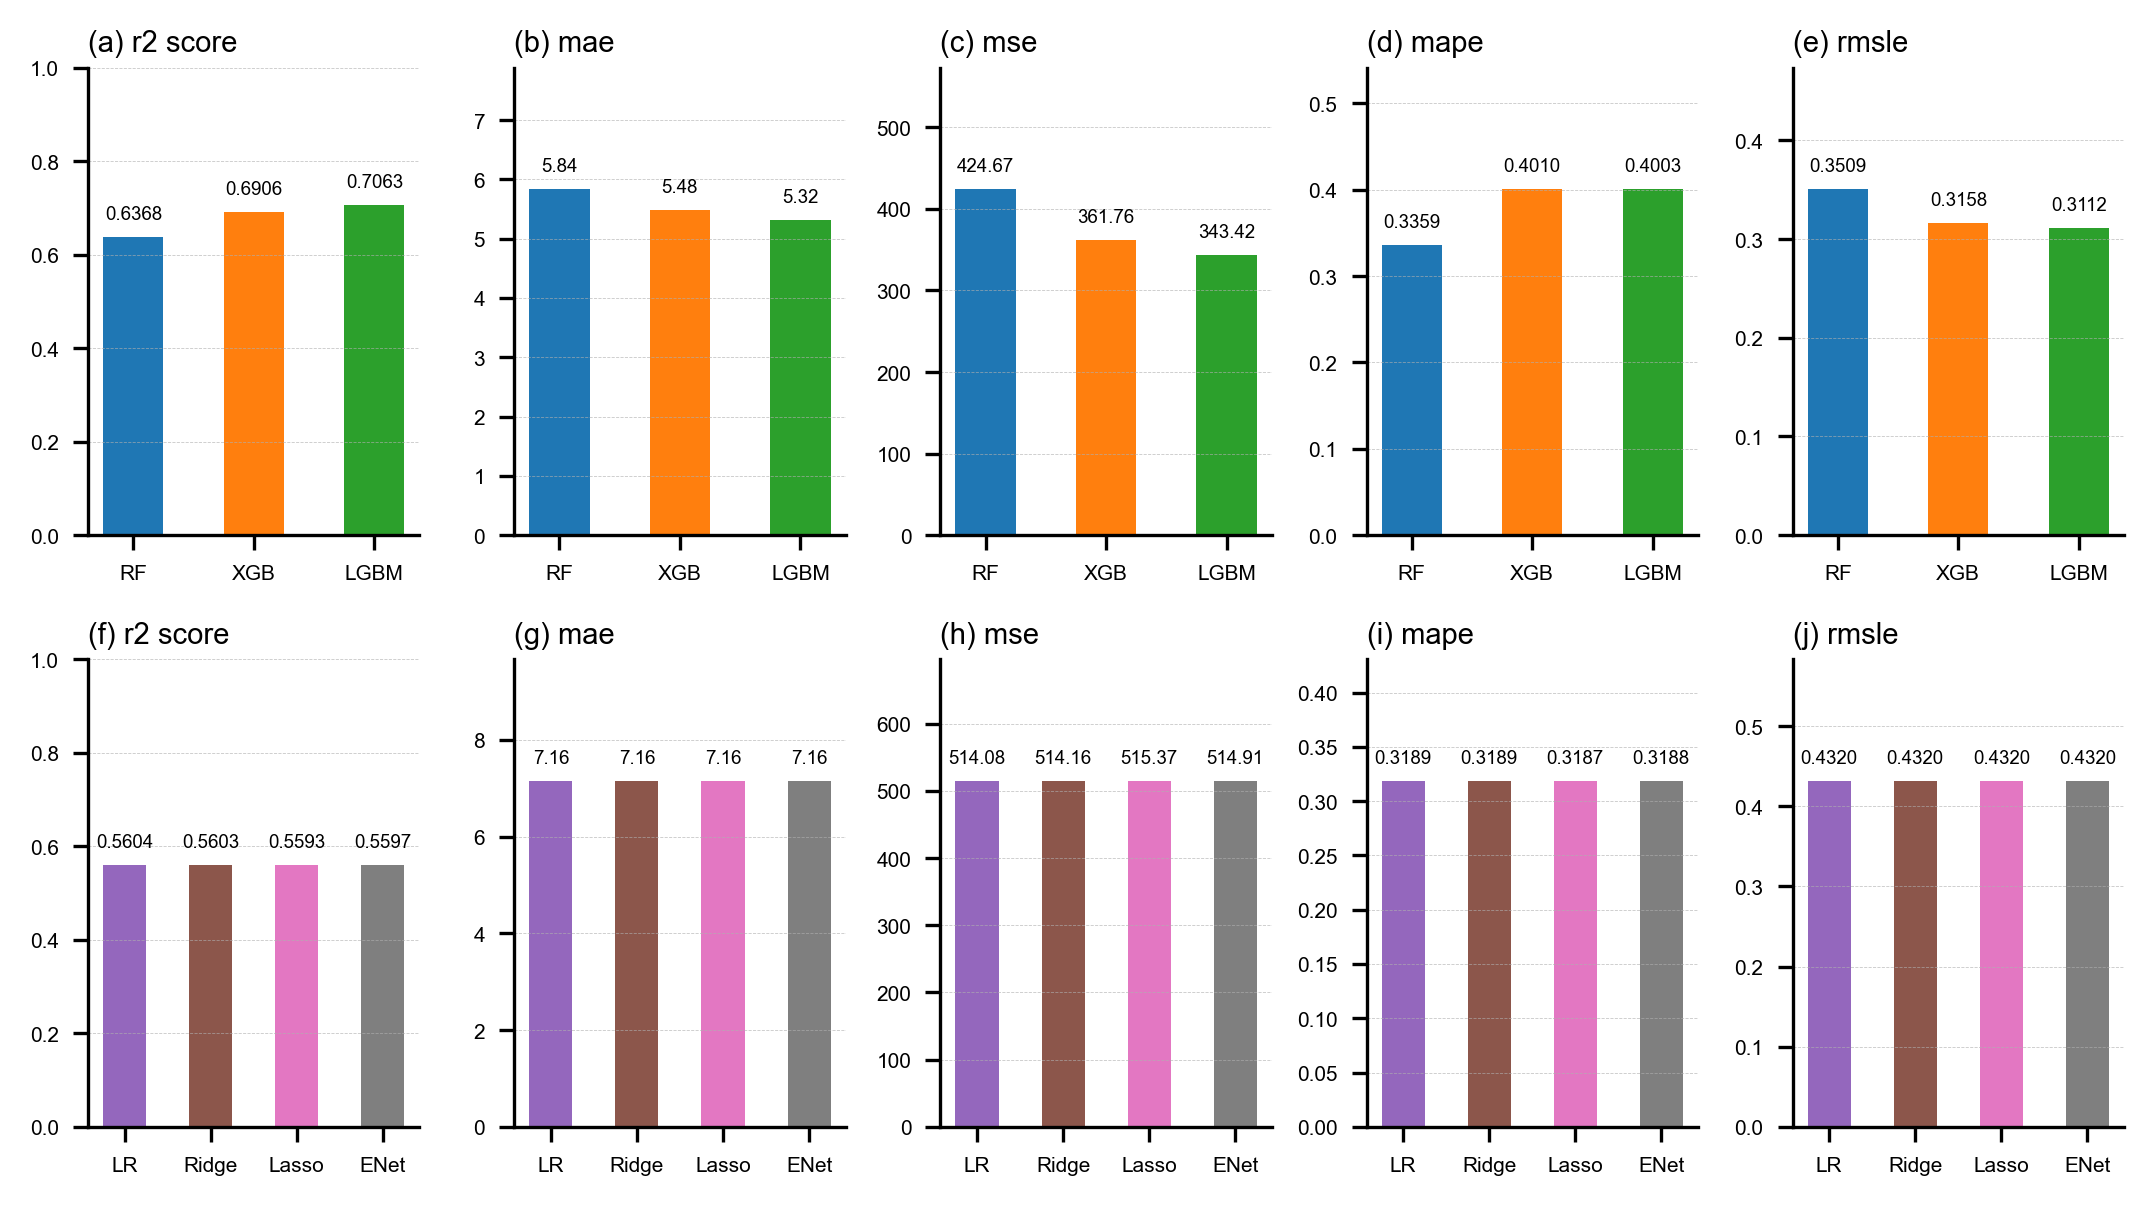

In [9]:
# ============================================================
# CELL 9 — COMBINED IEEE PANEL (2 × 5)
# ============================================================
plt.rcParams.update(IEEE_RC)

TREE_COLORS   = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
LINEAR_COLORS = ["#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
PANEL_ROW1    = ["(a)", "(b)", "(c)", "(d)", "(e)"]
PANEL_ROW2    = ["(f)", "(g)", "(h)", "(i)", "(j)"]

success_tree   = results_tree[results_tree["Status"] == "Success"].reset_index(drop=True)
success_linear = results_linear[results_linear["Status"] == "Success"].reset_index(drop=True)

assert not success_tree.empty,   "No successful tree models to plot"
assert not success_linear.empty, "No successful linear models to plot"

fig, axes = plt.subplots(2, 5, figsize=(7.16, 4.0), dpi=300)

tree_group   = "tree — log target" if IS_TARGET_LOGGED else "tree — raw target"
linear_group = "linear — log target"

for col_idx, metric in enumerate(METRICS):
    plot_metric_bars(
        axes[0, col_idx], success_tree,
        metric, TREE_COLORS,
        f"{PANEL_ROW1[col_idx]}",
    )
    plot_metric_bars(
        axes[1, col_idx], success_linear,
        metric, LINEAR_COLORS,
        f"{PANEL_ROW2[col_idx]}",
    )

plt.tight_layout(w_pad=1.0, h_pad=1.5)
plt.savefig("combined_experiments_ieee.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Individual Experiment Charts

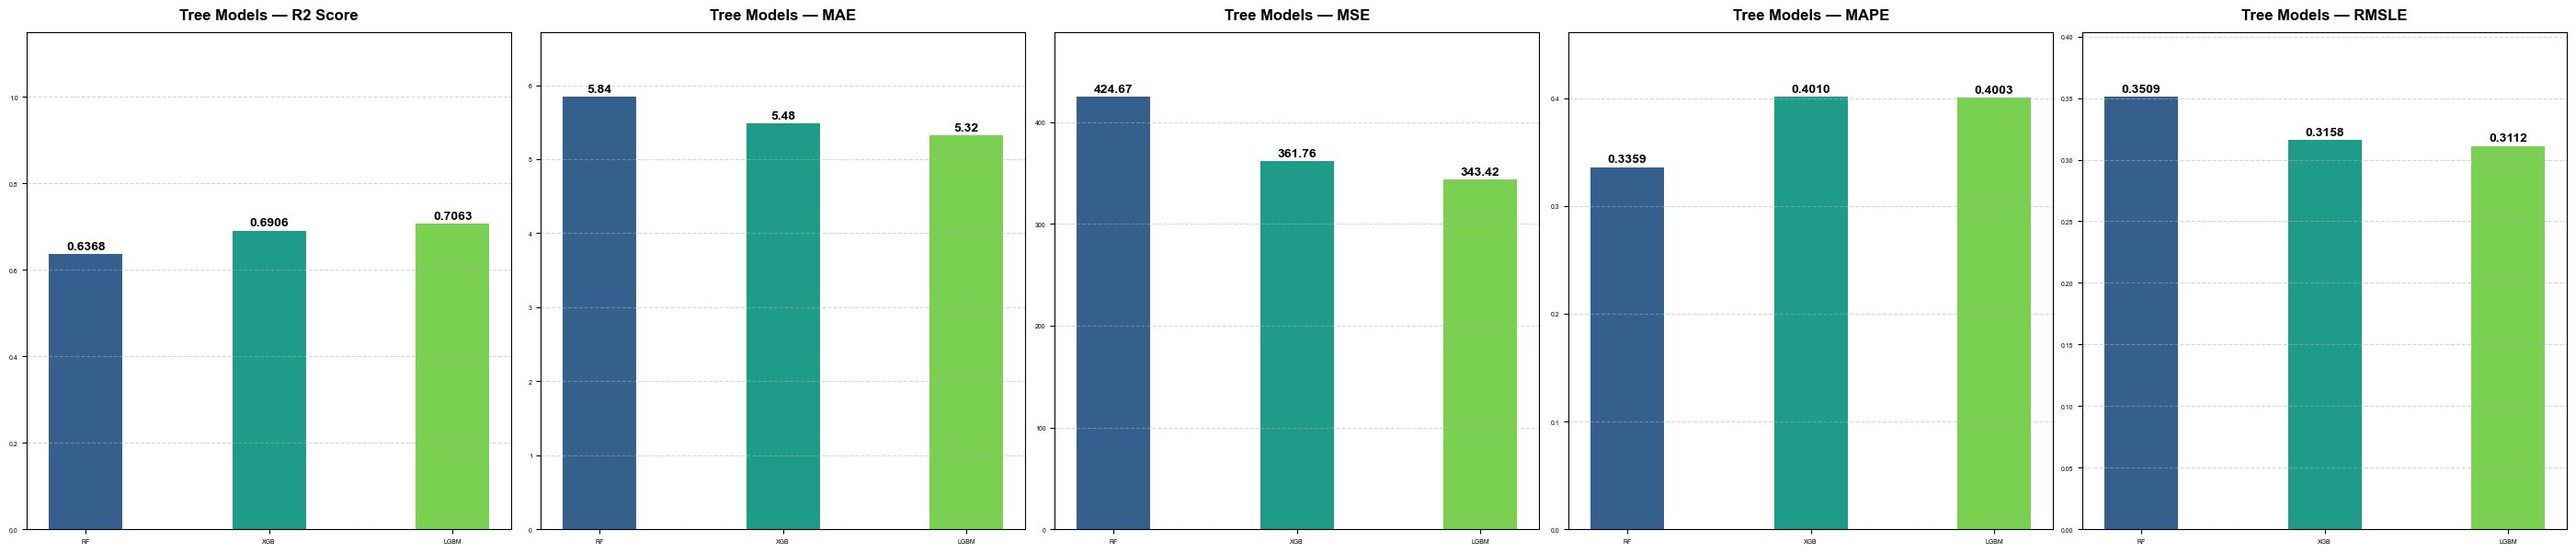

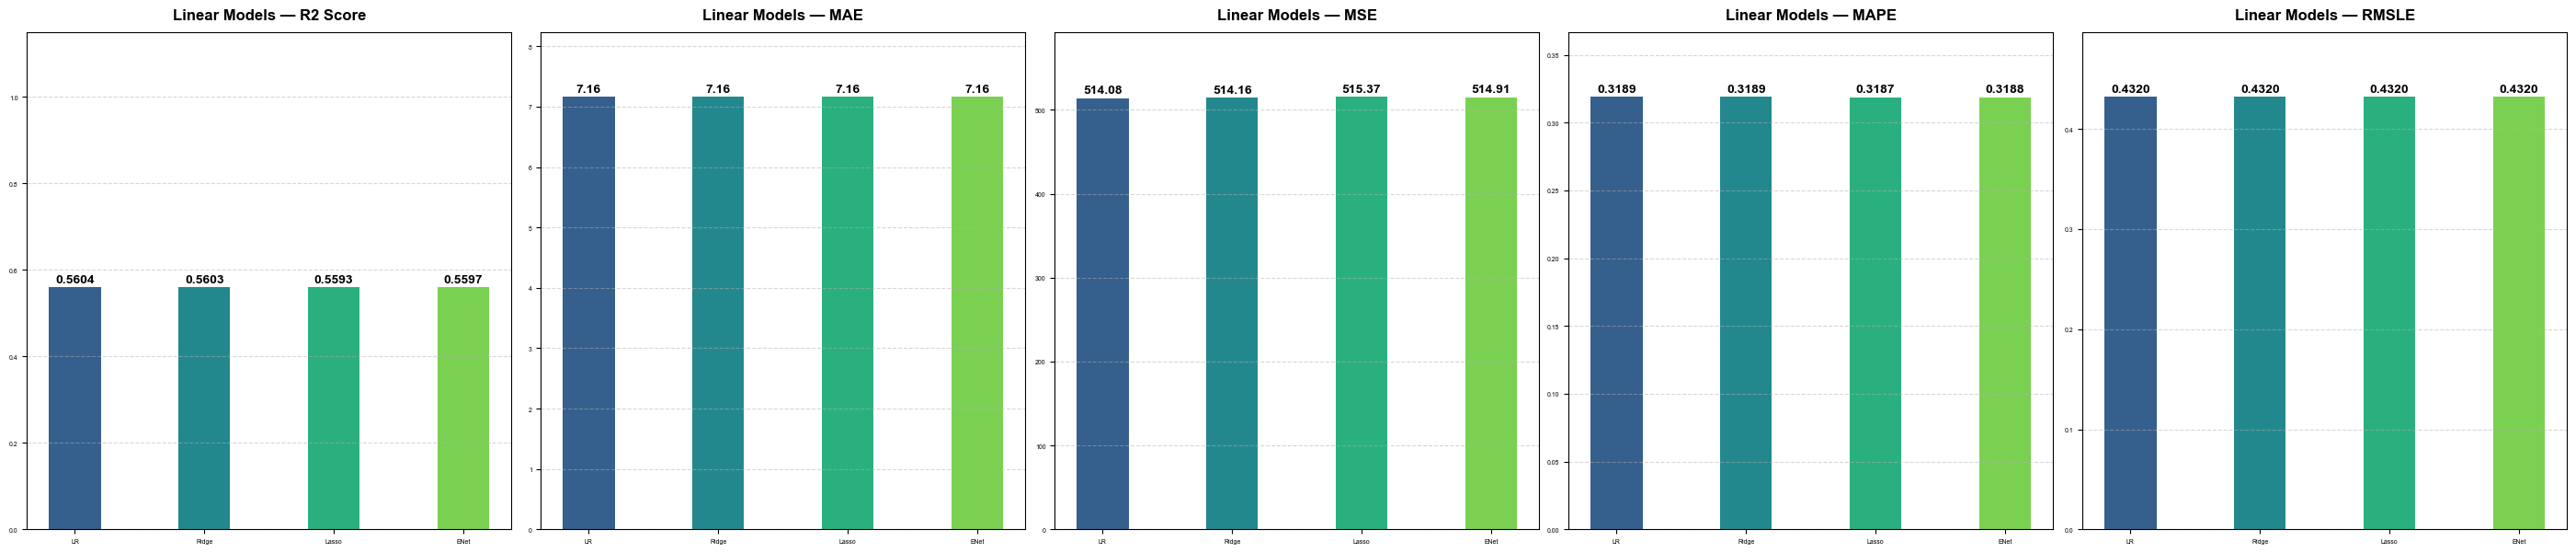

In [10]:
# ============================================================
# CELL 10 — INDIVIDUAL EXPERIMENT CHARTS
# ============================================================
def plot_experiment(df: pd.DataFrame, colors: list, title_prefix: str) -> None:
    """Draw a 1 × 5 bar chart for a single experiment group."""
    success = df[df["Status"] == "Success"].reset_index(drop=True)
    if success.empty:
        print(f"No successful models for {title_prefix}")
        return

    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    bar_colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(success)))

    for i, metric in enumerate(METRICS):
        ax   = axes[i]
        vals = success[metric].values
        names = success["Model"].map(MODEL_ABBR).fillna(success["Model"]).values
        bars = ax.bar(names, vals, color=bar_colors, width=0.4)

        ax.set_title(f"{title_prefix} — {metric}", fontsize=12, fontweight="bold", pad=10)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        max_val = np.nanmax(vals) if len(vals) else 1
        ax.set_ylim(0, 1.15 if metric == "R2 Score" else max_val * 1.15)

        for bar in bars:
            h = bar.get_height()
            fmt = f"{h:,.4f}" if metric in ("R2 Score", "MAPE", "RMSLE") else f"{h:,.2f}"
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                h + ax.get_ylim()[1] * 0.01,
                fmt, ha="center", fontweight="bold", fontsize=10,
            )

    plt.tight_layout()
    plt.show()


plot_experiment(results_tree,   TREE_COLORS,   "Tree Models")
plot_experiment(results_linear, LINEAR_COLORS, "Linear Models")

## 11. Final Summary Table

In [11]:
# ============================================================
# CELL 11 — FINAL SUMMARY TABLE
# ============================================================
results_tree["Group"]   = "Tree"
results_linear["Group"] = "Linear"

all_results = pd.concat([results_tree, results_linear], ignore_index=True)
all_results["Model_Short"] = all_results["Model"].map(MODEL_ABBR).fillna(all_results["Model"])

summary = (
    all_results[all_results["Status"] == "Success"]
    .sort_values("R2 Score", ascending=False)
    [["Group", "Model_Short", "R2 Score", "MAE", "MSE", "MAPE", "RMSLE"]]
    .reset_index(drop=True)
)

print("\n=== Final Model Ranking (by R2 Score) ===")
print(summary.to_string(index=False))


=== Final Model Ranking (by R2 Score) ===
 Group Model_Short  R2 Score  MAE    MSE   MAPE  RMSLE
  Tree        LGBM    0.7063 5.32 343.42 0.4003 0.3112
  Tree         XGB    0.6906 5.48 361.76 0.4010 0.3158
  Tree          RF    0.6368 5.84 424.67 0.3359 0.3509
Linear          LR    0.5604 7.16 514.08 0.3189 0.4320
Linear       Ridge    0.5603 7.16 514.16 0.3189 0.4320
Linear        ENet    0.5597 7.16 514.91 0.3188 0.4320
Linear       Lasso    0.5593 7.16 515.37 0.3187 0.4320
